In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# !mkdir -p /content/drive/MyDrive/project_object_detection/sets/nuimages 

# !wget https://www.nuscenes.org/data/nuimages-v1.0-mini.tgz  # Download the nuImages mini split.

# !tar -xf nuimages-v1.0-mini.tgz -C /content/drive/MyDrive/project_object_detection/sets/nuimages  # Uncompress the nuImages mini split.

!pip install nuscenes-devkit &> /dev/null 

In [ ]:
# %cd /content/drive/MyDrive/project_object_detection/
# !git clone https://github.com/ultralytics/yolov5  # clone
# !cd yolov5
!pip install -r /content/drive/MyDrive/project_object_detection/yolov5/requirements.txt 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.0/883.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.1 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/torch/hub.py:295: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2024-10-8 Python-3.10.12 torch-2.4.1+cu121 CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 133MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 900x1600 5 persons, 6 cars, 1 truck, 1 traffic light, 1 bench
Speed: 891.7ms pre-process, 282.4ms inference, 35.8ms NMS per image at shape (1, 3, 384, 640)


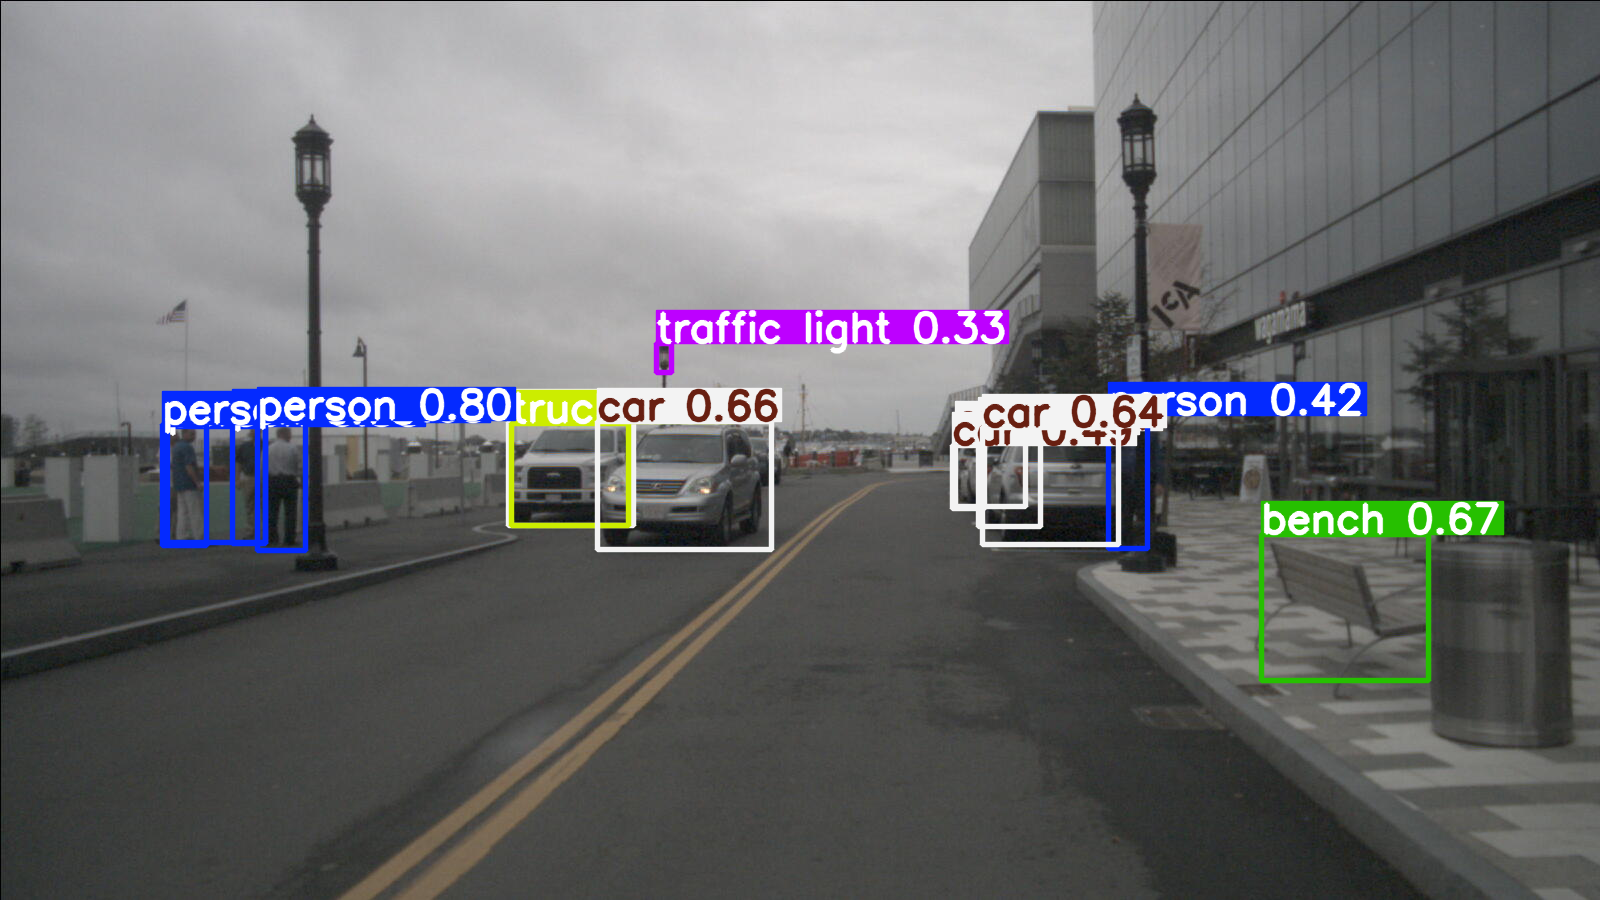

In [ ]:
import torch

# Model
model = torch.hub.load("ultralytics/yolov5", "yolov5s") 

# Images
img = "/content/drive/MyDrive/project_object_detection/sets/nuimages/samples/CAM_FRONT/n009-2018-09-12-09-59-51-0400__CAM_FRONT__1536761961012656.jpg"  # or file, Path, PIL, OpenCV, numpy, list

# Inference
results = model(img)

# Results
results.print()  # or .show(), .save(), .crop(), .pandas(), etc.
results.show()

df = results.pandas().xyxy[0]
car_count = (df['name'] == 'car').sum()
print(f"Number of cars detected: {car_count}")

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-10-8 Python-3.10.12 torch-2.4.1+cu121 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 900x1600 5 persons, 6 cars, 1 truck, 1 traffic light, 1 bench
Speed: 27.0ms pre-process, 276.9ms inference, 3.4ms NMS per image at shape (1, 3, 384, 640)


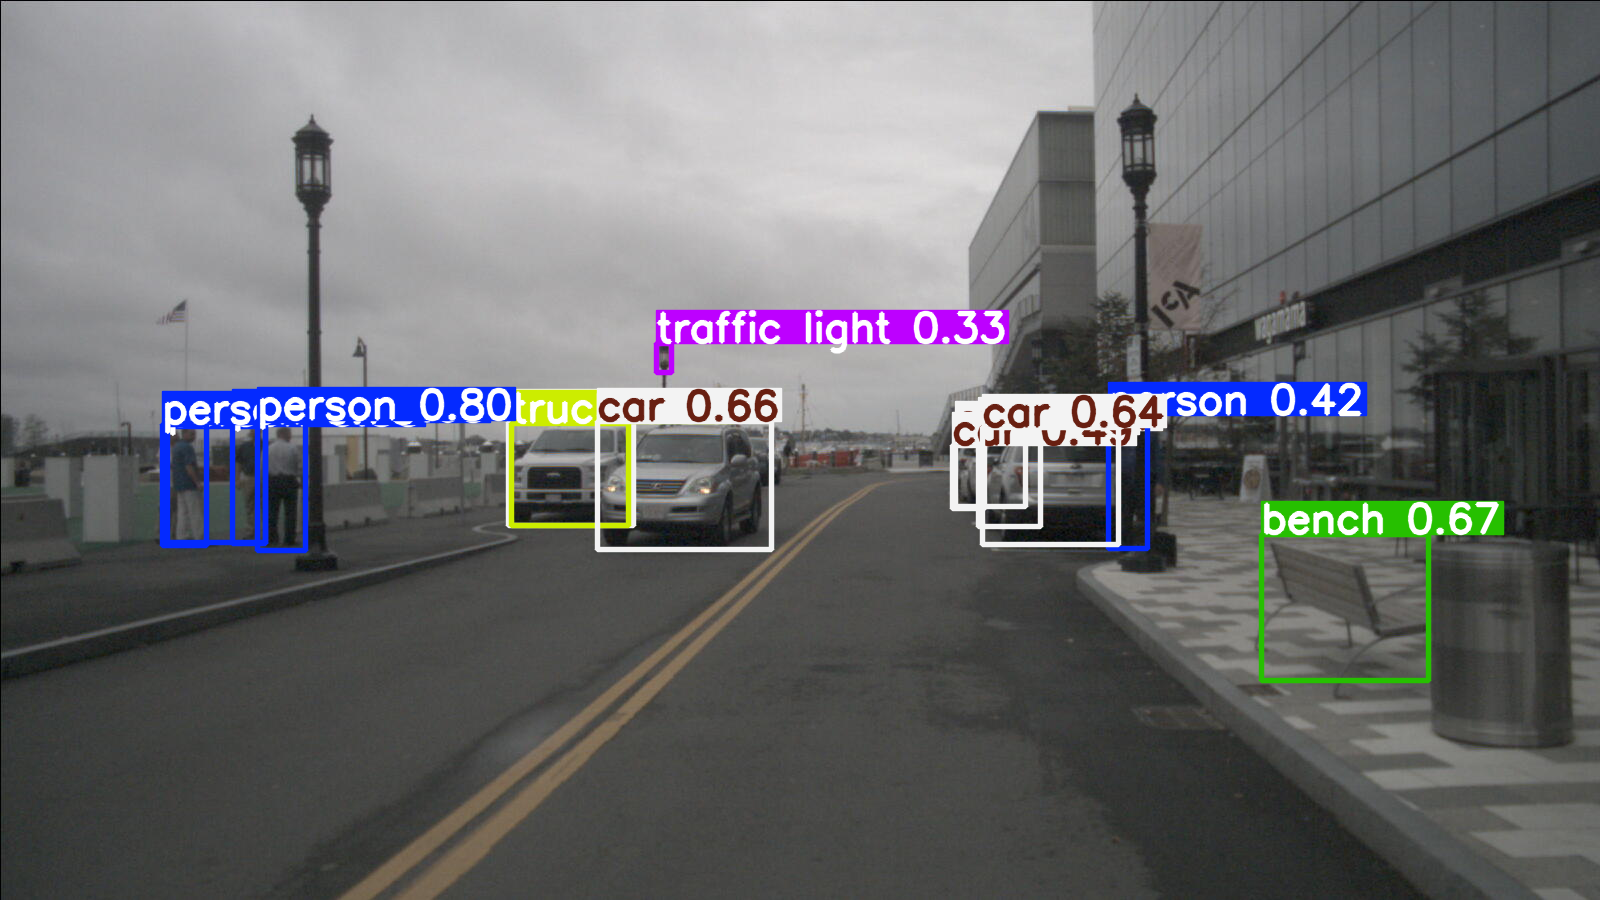

Bounding box: (257.5459289550781, 420.1977233886719), (305.36126708984375, 550.412109375) with confidence 0.7999575734138489 and class person
Bounding box: (162.53211975097656, 424.1542053222656), (206.14524841308594, 545.6968383789062) with confidence 0.7469251751899719 and class person
Bounding box: (1261.2921142578125, 534.62109375), (1428.05419921875, 680.482177734375) with confidence 0.6668293476104736 and class bench
Bounding box: (597.042236328125, 421.4720153808594), (771.011474609375, 549.4601440429688) with confidence 0.6634148359298706 and class car
Bounding box: (232.30535888671875, 422.3639221191406), (265.64874267578125, 543.2927856445312) with confidence 0.6530229449272156 and class person
Bounding box: (982.1665649414062, 427.9495849609375), (1118.6015625, 544.143310546875) with confidence 0.6391861438751221 and class car
Bounding box: (511.9731750488281, 423.02813720703125), (628.4550170898438, 525.150390625) with confidence 0.5477564334869385 and class truck
Bounding 

In [ ]:
import torch

# Model
model = torch.hub.load("ultralytics/yolov5", "yolov5s")  # or yolov5n - yolov5x6, custom

# Images
img = "/content/drive/MyDrive/project_object_detection/sets/nuimages/samples/CAM_FRONT/n009-2018-09-12-09-59-51-0400__CAM_FRONT__1536761961012656.jpg"  # or file, Path, PIL, OpenCV, numpy, list

# Inference
results = model(img)

# Results
results.print()  # or .show(), .save(), .crop(), .pandas(), etc.
results.show()

# Print the coordinates of the bounding boxes and class names
for bbox in results.xyxy[0].numpy():
    x1, y1, x2, y2, conf, cls = bbox
    class_name = results.names[int(cls)]
    print(f"Bounding box: ({x1}, {y1}), ({x2}, {y2}) with confidence {conf} and class {class_name}")


Loading nuImages tables for version v1.0-mini...
Done loading in 0.000 seconds (lazy=True).
Loaded 650 sample_data(s) in 0.008s,
Loaded 50 sample(s) in 0.003s,
Key camera token: 928d3dd5359b4fa3b540646da963da7f
Loaded 58 surface_ann(s) in 0.486s,
Loaded 25 category(s) in 0.456s,
Loaded 506 object_ann(s) in 0.371s,
Loaded 12 attribute(s) in 0.369s,
Printing object annotations:
0d883fc0cf7a48f4b41da6cb74267b1d movable_object.barrier []
1fa5d7aea85c4c06a2da93d272ee5a99 vehicle.truck ['vehicle.parked']
3266fae0bbc54a9a9a5b21ab9c192f1d vehicle.car ['vehicle.parked']
6cccdd4ccdf443b8a40afe191685b2e7 human.pedestrian.adult ['pedestrian.standing']
9d3ea7723165410daae4cf30bb4db3c6 vehicle.car ['vehicle.parked']
9fe19fb83cde47e98ef0d040b3ee82f6 human.pedestrian.adult ['pedestrian.standing']
adeedf8bbc55441f9396500cedca08fb vehicle.car ['vehicle.parked']
afa838007d48409891dbae00272ef61b vehicle.car ['vehicle.moving']
b1e20788c37b4bf8abb94ec6d2dd7f3c human.pedestrian.adult ['pedestrian.standing']


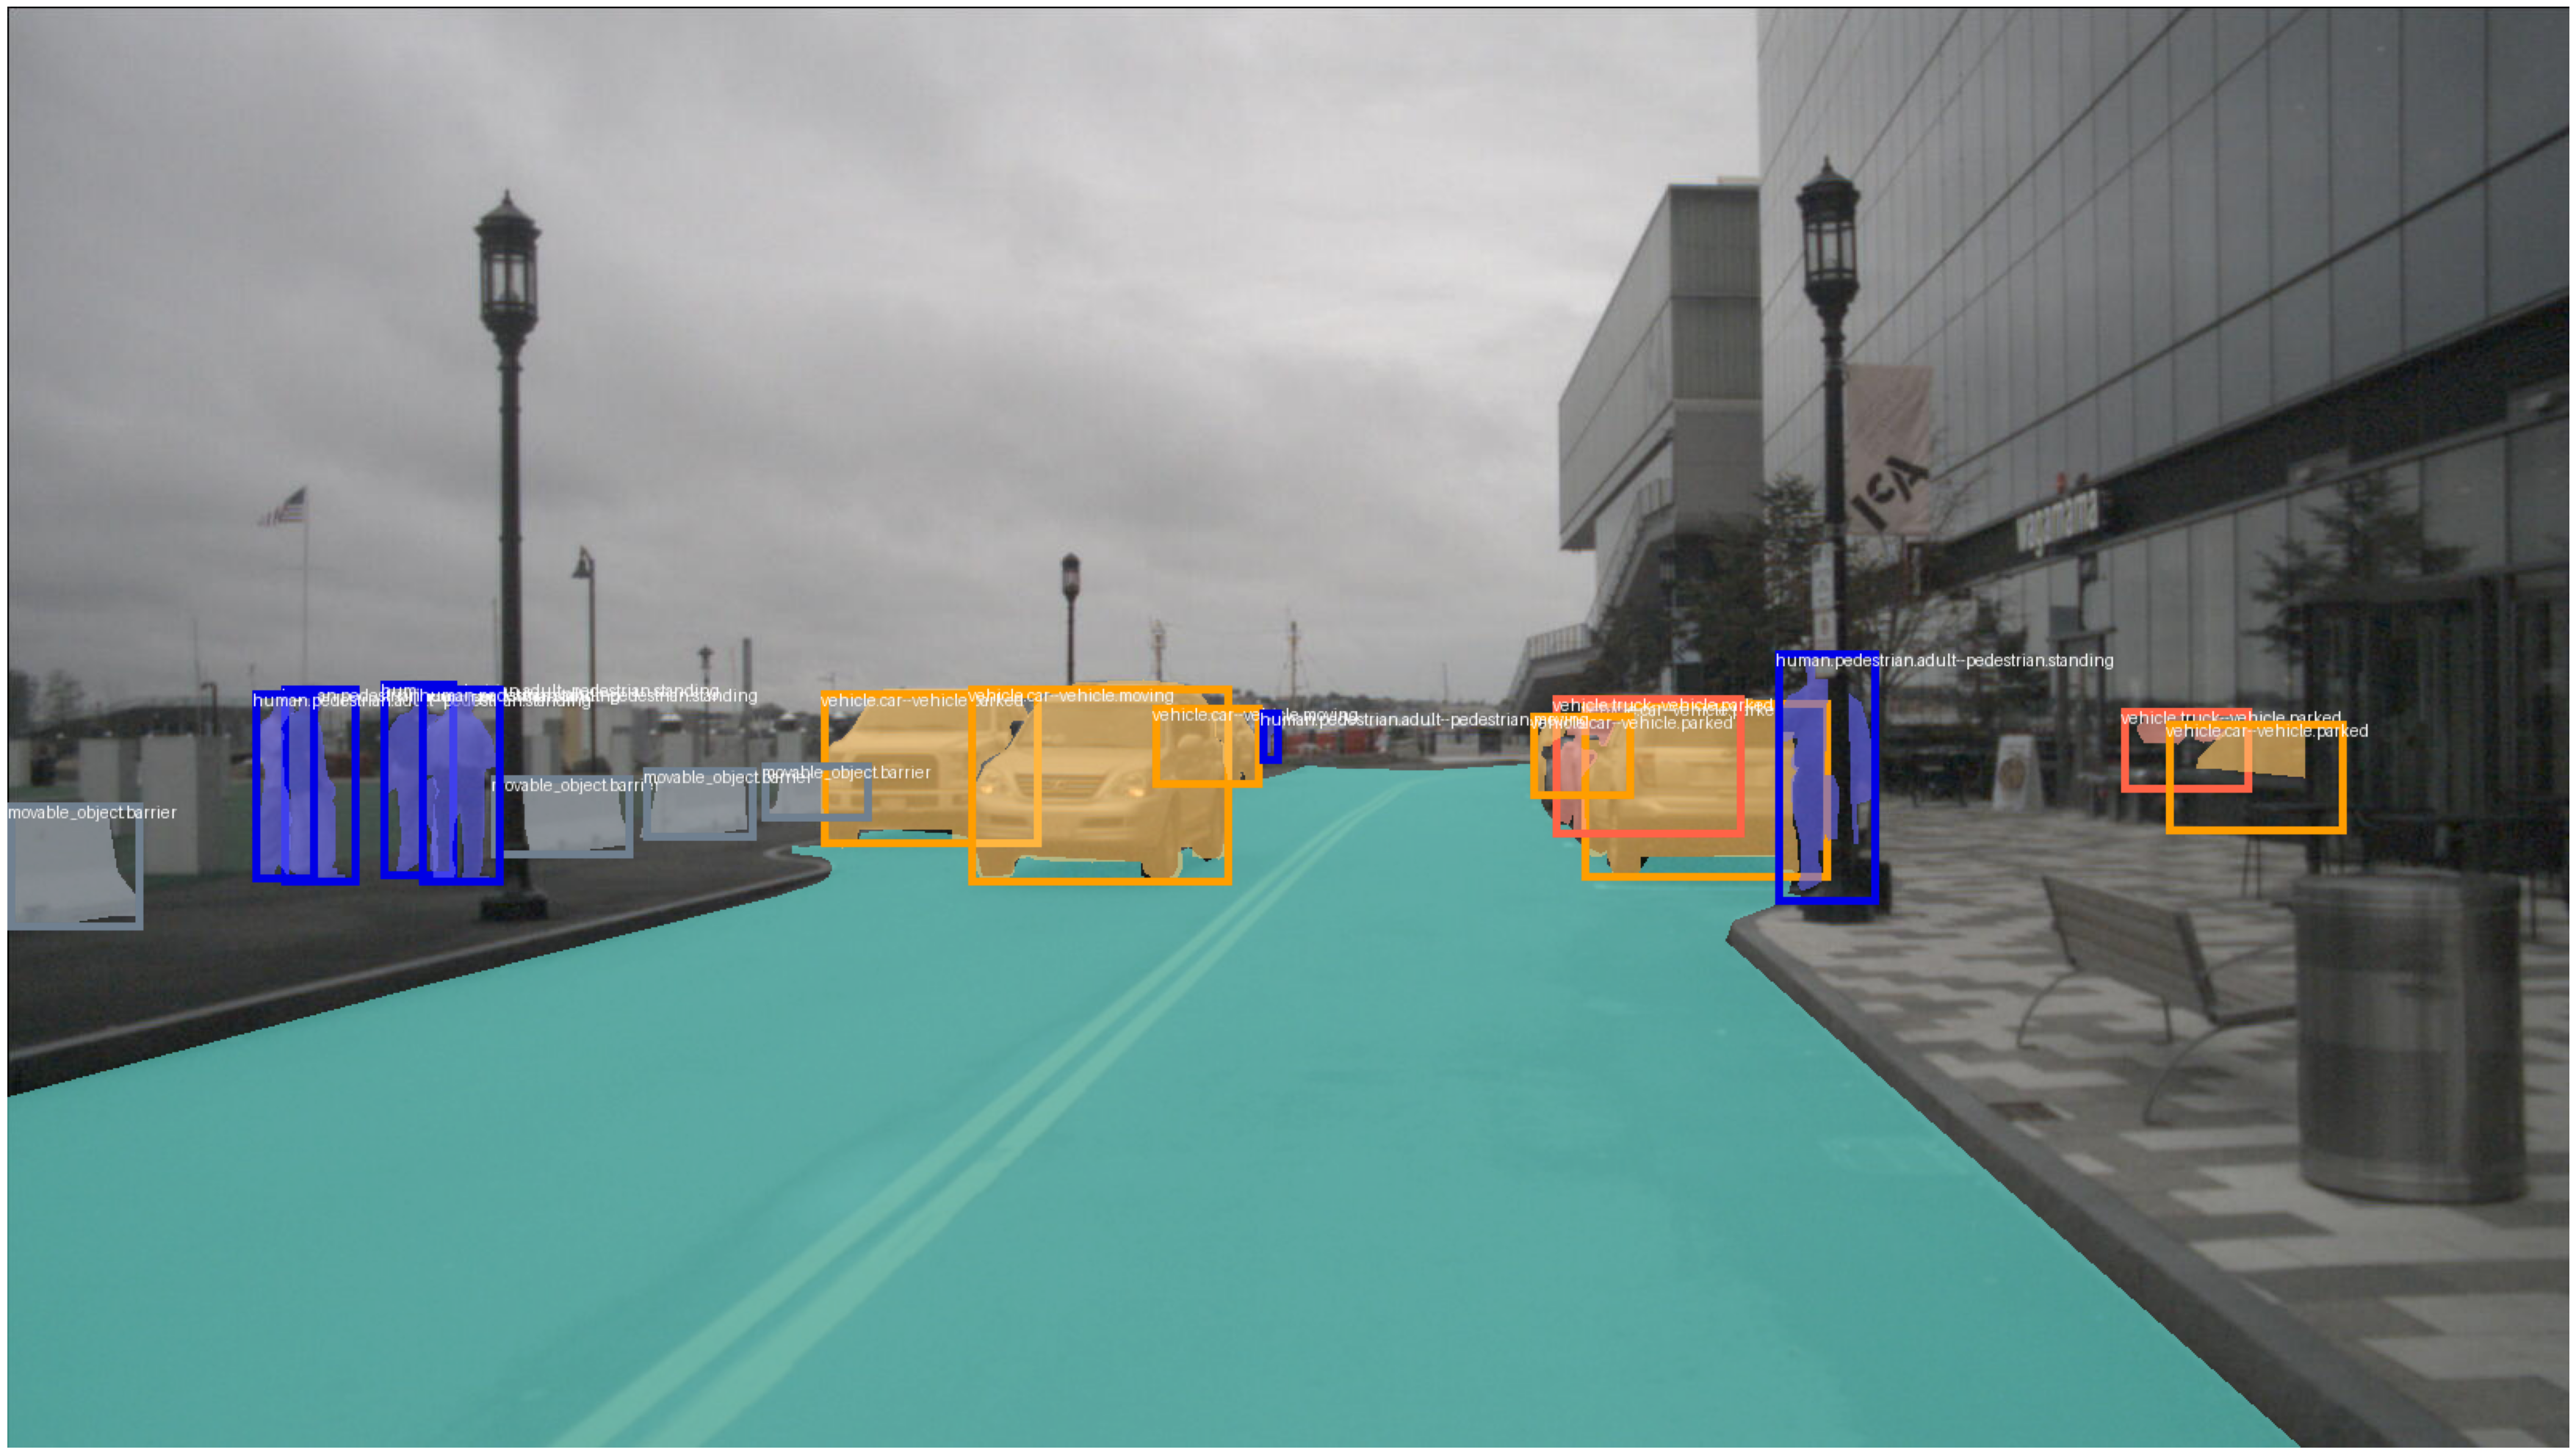

In [ ]:
#This code gives the ground truth for NuImages dataset


from nuimages import NuImages

# Initialize the dataset
nuim = NuImages(dataroot='/content/drive/MyDrive/project_object_detection/sets/nuimages', version='v1.0-mini', verbose=True, lazy=True)

# Path to your image
image_path = 'samples/CAM_FRONT/n009-2018-09-12-09-59-51-0400__CAM_FRONT__1536761961012656.jpg'

# Find the sample data record
sample_data = next(sd for sd in nuim.sample_data if sd['filename'] == image_path)
sample_data_token = sample_data['token']

# Get the sample record
sample = nuim.get('sample', sample_data['sample_token'])

# Verify the sample index
sample_idx_check = nuim.getind('sample', sample['token'])
assert sample_idx_check == nuim.getind('sample', sample['token'])

# Get the key camera token
key_camera_token = sample['key_camera_token']
print(f"Key camera token: {key_camera_token}")

# Render the image with annotations
nuim.render_image(key_camera_token, annotation_type='all', with_category=True, with_attributes=True, box_line_width=-1, render_scale=5)

# List the annotations
object_tokens, surface_tokens = nuim.list_anns(sample['token'])

# Print the ground truth annotations
for object_token in object_tokens:
    ann = nuim.get('object_ann', object_token)
    bbox = ann['bbox']
    category = nuim.get('category', ann['category_token'])['name']
    print(f"Bounding box: {bbox} with category: {category}")


In [ ]:
import torch
import cv2
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load YOLOv5 model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

# Define the video input and output paths
input_video_path = '/content/drive/MyDrive/project_object_detection/sets/videos/self-driving-car-front-camera.mp4' # number of frames = 1878
output_video_path = '/content/drive/MyDrive/project_object_detection/sets/videos/self-driving-car-front-camera-vehicle-tracking.mp4'

# Known average height of a car (in meters)
CAR_HEIGHT = 1.5

# Approximate camera parameters
FOCAL_LENGTH = 1000  # Adjust based on the camera

# Initialize video reader and writer
cap = cv2.VideoCapture(input_video_path)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

# To track the movement (left/right) of objects across frames
previous_positions = {}
frame_number = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_number+=1
    print("processing video frame number " + str(frame_number))
    # Perform inference on the frame
    results = model(frame)

    # Loop through the results
    current_positions = {}
    for *box, conf, cls in results.xyxy[0].cpu().numpy():
        x1, y1, x2, y2 = map(int, box)  # Bounding box coordinates
        label = int(cls)  # Class label

        if label == 2:  # Class 2 corresponds to 'car' in YOLOv5 COCO dataset
            # Compute bounding box height (in pixels)
            bbox_height_pixels = y2 - y1

            # Estimate distance to the car
            if bbox_height_pixels > 0:
                distance = (CAR_HEIGHT * FOCAL_LENGTH) / bbox_height_pixels

                # Draw bounding box
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

                # Prepare text for distance
                distance_text = f"Distance: {distance:.2f}m"

                # Tracking: check if the object moved left or right
                center_x = (x1 + x2) // 2  # Calculate center x-coordinate of the object

                # If the object was in the previous frame, compare its position
                movement = "Stationary"
                if label in previous_positions:
                    prev_x = previous_positions[label]  # Previous x-coordinate
                    if center_x > prev_x + 10:  # Threshold for detecting right movement
                        movement = "Right"
                    elif center_x < prev_x - 10:  # Threshold for detecting left movement
                        movement = "Left"

                # Update current position of the object for the next frame
                current_positions[label] = center_x

                # Display both distance and movement direction
                text = f"{distance_text}, Movement: {movement}"
                cv2.putText(frame, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # Update previous positions with current positions for tracking in the next frame
    previous_positions = current_positions

    # Write the frame with distance and movement information to the output video
    out.write(frame)

# Release video reader and writer
cap.release()
out.release()

print("Object detection, distance estimation, and movement tracking completed. Output saved to", output_video_path)

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-11-25 Python-3.10.12 torch-2.5.1+cu121 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


processing video frame number 1
processing video frame number 2
processing video frame number 3
processing video frame number 4
processing video frame number 5
processing video frame number 6
processing video frame number 7
processing video frame number 8
processing video frame number 9
processing video frame number 10
processing video frame number 11
processing video frame number 12
processing video frame number 13
processing video frame number 14
processing video frame number 15
processing video frame number 16
processing video frame number 17
processing video frame number 18
processing video frame number 19
processing video frame number 20
processing video frame number 21
processing video frame number 22
processing video frame number 23
processing video frame number 24
processing video frame number 25
processing video frame number 26
processing video frame number 27
processing video frame number 28
processing video frame number 29
processing video frame number 30
processing video fr